# 5. Inclination estimation and Fourier-domain compression

## The profile objective

The inclination $\beta$ enters the design matrix nonlinearly. jittermap
estimates it by minimizing the profile objective
$J(\beta) = \|\mathbf{y} - D(\beta)\hat{\mathbf{s}}(\beta)\|^2 +
\lambda \hat{\mathbf{s}}^H Q \hat{\mathbf{s}}$, where
$\hat{\mathbf{s}}(\beta)$ is the MAP solution at each trial inclination.
Scanning $J(\beta)$ makes the paper's identifiability statement visible:
with photometry alone the objective is shallow (inclination ambiguity even
at infinite SNR); astrometry sharpens it.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import jittermap as jm


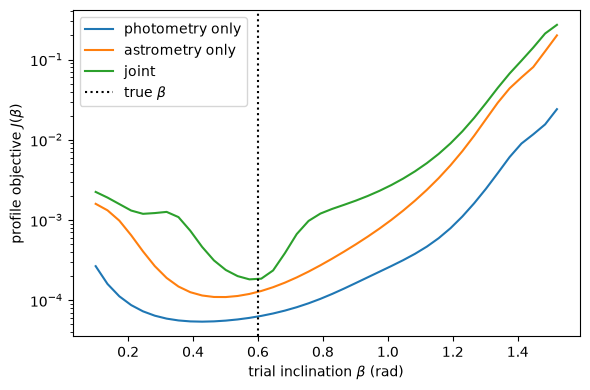

In [2]:
from jittermap.inference.inclination import profile_objective

L, N = 10, 100
INC_TRUE = 0.6
times = np.linspace(0, 2*np.pi, N, endpoint=False)
s_true = jm.multispot_surface([(30, 315, 18.0), (-15, 30, 13.0)], L,
                              texture_amplitude=0.002, texture_seed=3)
fm = jm.ForwardModel(times, l_max=L)
y = fm.observe(s_true, inclination=INC_TRUE, channels="xyp", stacked=False)

betas = np.linspace(0.1, np.pi/2 - 0.05, 40)
plt.figure(figsize=(6, 4))
for ch, label in [("p", "photometry only"), ("xy", "astrometry only"),
                  ("xyp", "joint")]:
    y_vec = np.concatenate([y[c] for c in ch])
    J = [profile_objective(b, y_vec, ch, L, fm.kernels, fm._precomp, lam=2e-4)
         for b in betas]
    plt.semilogy(betas, J, label=label)
plt.axvline(INC_TRUE, color="k", ls=":", label="true $\\beta$")
plt.xlabel("trial inclination $\\beta$ (rad)")
plt.ylabel("profile objective $J(\\beta)$")
plt.legend(); plt.tight_layout()

In [3]:
for ch in ["p", "xy", "xyp"]:
    res = jm.reconstruct({c: y[c] for c in ch}, times, L, channels=ch,
                         lam=2e-4, model=fm)
    print(f"channels={ch:3s}: estimated inclination {res.inclination:.3f} "
          f"(true {INC_TRUE})")

channels=p  : estimated inclination 0.426 (true 0.6)


channels=xy : estimated inclination 0.484 (true 0.6)


channels=xyp: estimated inclination 0.588 (true 0.6)


## Fourier-domain compression

For $N \ge 2L+1$ uniform samples over one rotation, the time matrix
$W_\omega$ is unitary and the signal is a frequency comb at harmonics
$m\omega$, $m = -L..L$ (paper Section 2.1). Projecting onto the comb
compresses each channel from $N$ samples to $2L+1$ coefficients with **no
information loss**, and the design matrix becomes the small
inclination-dependent block $B_\beta$ directly:

In [4]:
from jittermap.forward.fourier import compress, fourier_design_matrix, \
    fourier_to_real
from jittermap.forward.kernels import compute_A_lm

A_x, _ = compute_A_lm(L)
y_x = fm.observe(s_true, INC_TRUE, channels="x")
f_from_time = compress(y_x, L)              # (2L+1,) complex
F = fourier_design_matrix(L, INC_TRUE, A_x)  # (2L+1, (L+1)^2)
f_direct = F @ s_true
print("compressed observation matches F @ s:",
      np.allclose(f_from_time, f_direct, atol=1e-12))
print(f"compression: {N} time samples -> {2*L+1} Fourier coefficients")

compressed observation matches F @ s: True
compression: 100 time samples -> 21 Fourier coefficients


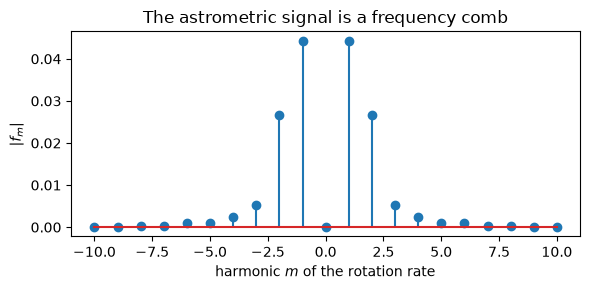

In [5]:
m_vals = np.arange(-L, L+1)
plt.figure(figsize=(6, 3))
plt.stem(m_vals, np.abs(f_from_time))
plt.xlabel("harmonic $m$ of the rotation rate")
plt.ylabel("$|f_m|$")
plt.title("The astrometric signal is a frequency comb")
plt.tight_layout()

Because the compressed coefficients of a real signal obey
$f_{-m} = f_m^*$, they repack losslessly into $2L+1$ real numbers
(`fourier_to_real` / `real_to_fourier`) — the observation format used for
compact inference.

In [6]:
x_real = fourier_to_real(f_from_time)
print("real-packed observation vector:", x_real.shape)

real-packed observation vector: (21,)
